In [47]:
import os
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

IMG_SIZE=64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scale to [-1, 1]
    ])
aug_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scale to [-1, 1]
    ])


def get_dataloaders(data_dir, batch_size=32, shuffle=True, transform=val_transform):
    # standard preprocessing for VAEs

    # Load the full dataset
    full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    
    # Filter for only Cats (label 0) and Dogs (label 1) 
    # AFHQ structure is usually: 0:cat, 1:dog, 2:wild
    indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label in [0, 1]]
    cat_dog_dataset = Subset(full_dataset, indices)
    
    loader = DataLoader(cat_dog_dataset, batch_size=batch_size, shuffle=shuffle)
    return loader, full_dataset.classes

def visualize_transformation(model, dataloader, device):
    model.eval()
    images, labels = next(iter(dataloader))
    
    # Pick only the cats from the batch
    cat_indices = (labels == 0).nonzero(as_tuple=True)[0]
    if len(cat_indices) == 0: return
    
    cats = images[cat_indices[:4]].to(device)
    
    with torch.no_grad():
        # 1. Encode Cats
        mu, _ = model.encode(cats, torch.zeros(len(cats), dtype=torch.long).to(device))
        
        # 2. Decode as Dogs (Label 1)
        dog_labels = torch.ones(len(cats), dtype=torch.long).to(device)
        transformed_dogs = model.decode(mu, dog_labels)

    # Plotting
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i in range(len(cats)):
        # Show Original Cat
        orig = cats[i].cpu() * 0.5 + 0.5
        axes[0, i].imshow(np.transpose(orig, (1, 2, 0)))
        axes[0, i].set_title("Original Cat")
        axes[0, i].axis('off')
        
        # Show Transformed Dog
        trans = transformed_dogs[i].cpu() * 0.5 + 0.5
        axes[1, i].imshow(np.transpose(trans, (1, 2, 0)))
        axes[1, i].set_title("Transformed Dog")
        axes[1, i].axis('off')
    plt.show()

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(dataloader, classes):
    images, labels = next(iter(dataloader))
    
    # Un-normalize for visualization
    images = images * 0.5 + 0.5 
    
    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        plt.title(f"Label: {classes[labels[i]]}")
        plt.axis('off')
    plt.show()

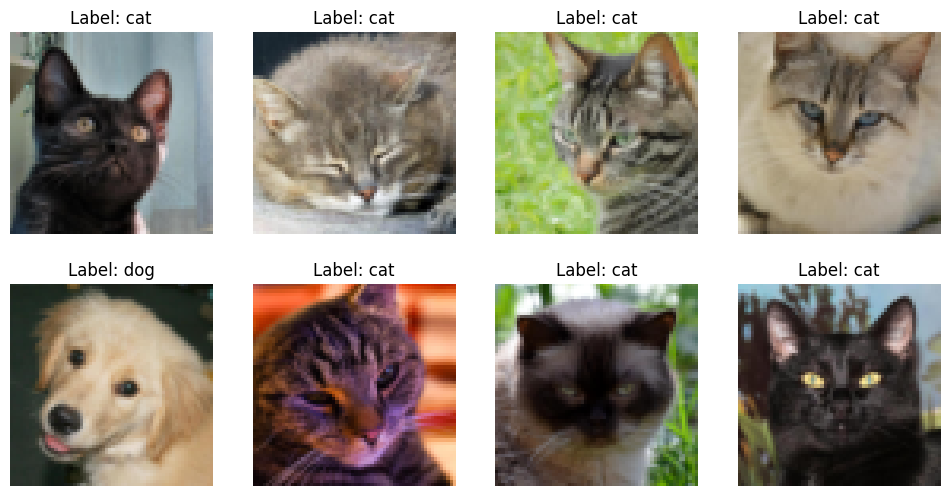

In [ ]:
# Setup
train_loader, train_classes = get_dataloaders("./afhq/train")
show_batch(train_loader, train_classes)

## Model Architecture

The architecture chosen is a Conditional Variational Autoencoder optimized for 64×64 image generation. Unlike a standard VAE, it injects class information at both the encoder and decoder to allow for specific species generation (Cat vs. Dog).

Mechanism: In the Encoder, the class label is broadcast spatially and concatenated as a 4th input channel, allowing the network to extract features conditioned on the class. We use Strided Convolutions (kernel 4, stride 2) instead of pooling layers to preserve high-frequency texture details (fur/whiskers). The Decoder receives the sampled latent vector (z) concatenated with a learned Class Embedding (dim=64). It progressively upsamples using Transposed Convolutions and LeakyReLU activations. The final output layer uses a Tanh activation to strictly map pixel values to the normalized range [−1,1].

Data Flow & Dimensions:

    Input: Image (3,64,64) ⊕ Label Plane → Encoder (4 Layers) → Flatten

    Latent Space: μ,logσ (Linear) → Reparameterize (z ∈ R^128)

    Decode: z ⊕ Label Emb (64) → Decoder (4 Layers) → Tanh → Output (3,64,64)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SharpCVAE(nn.Module):
    def __init__(self, latent_dim=128, num_classes=2, img_channels=3):
        super(SharpCVAE, self).__init__()
        self.latent_dim = latent_dim
        
        # We need this for the Decoder
        self.label_emb = nn.Embedding(num_classes, 64)
        
        # --- Encoder ---
        # Input is Image (3) + Label Plane (1) = 4 channels
        self.encoder = nn.Sequential(
            nn.Conv2d(img_channels + 1, 64, 4, 2, 1), # 64x64 -> 32x32
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, 4, 2, 1), # 32x32 -> 16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, 4, 2, 1), # 16x16 -> 8x8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, 4, 2, 1), # 8x8 -> 4x4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )
        
        self.flatten_dim = 512 * 4 * 4
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)
        
        # --- Decoder ---
        # Latent (128) + Label Embedding (64) = 192
        self.decoder_input = nn.Linear(latent_dim + 64, self.flatten_dim)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Output: Tanh for [-1, 1] range (Sharper than Sigmoid)
            nn.ConvTranspose2d(64, img_channels, 4, 2, 1),
            nn.Tanh() 
        )

    def encode(self, x, y):
        y_encoded = y.view(-1, 1, 1, 1).float().expand(-1, 1, x.size(2), x.size(3))
        x_cond = torch.cat([x, y_encoded], dim=1)
        out = self.encoder(x_cond)
        out = torch.flatten(out, start_dim=1)
        return self.fc_mu(out), self.fc_logvar(out)

    def reparameterize(self, mu, logvar):
        logvar = torch.clamp(logvar, min=-10, max=10)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y_emb = self.label_emb(y)
        z_cond = torch.cat([z, y_emb], dim=1)
        
        out = self.decoder_input(z_cond)
        out = out.view(-1, 512, 4, 4)
        return self.decoder(out)

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, y), mu, logvar

# Training util functions

In [80]:
import torchvision.models as models

def get_kl_weight(epoch, total_epochs):
    # Cyclic Annealing: Linearly increase weight, then reset, then increase again.
    # This helps the model escape "clumped" local minima.
    cycle_len = total_epochs // 4
    cycle_idx = epoch % cycle_len
    
    # Target max weight (tune this: 0.001 to 0.01 is usually good for images)
    max_kl = 0.005 
    
    # Linear ramp up
    weight = (cycle_idx / cycle_len) * max_kl
    return weight
    

def loss_function(recon_x, x, mu, logvar, beta=1.0):
    # Reconstruction loss (MSE or BCE)
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    # KL Divergence: forces latent space to be normal distribution
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld_loss * beta

In [81]:
def train_epoch(model, dataloader, optimizer, device, epoch, num_epochs):
    model.train()
    train_loss = 0
    weight = get_kl_weight(epoch, num_epochs)
    for batch_idx, (data, labels) in enumerate(dataloader):
        data, labels = data.to(device), labels.to(device)
        if batch_idx == 0 and epoch == 1:
            if data.max() > 1.0 or data.min() < -1.0:
                print(f"WARNING: Data range is [{data.min()}, {data.max()}]. Model expects [-1, 1]")
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, mu, logvar = model(data, labels)
        # Calculate loss
        loss = loss_function(recon_batch, data, mu, logvar, weight)
        
        # Backward pass
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    avg_loss = train_loss / len(dataloader.dataset)
    return avg_loss

def validate_epoch(model, dataloader, device):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)
            
            recon_batch, mu, logvar = model(data, labels)
            loss = loss_function(recon_batch, data, mu, logvar, 0.00025)
            val_loss += loss.item()
            
    avg_loss = val_loss / len(dataloader.dataset)
    return avg_loss

# Training Loop

In [107]:
from copy import deepcopy

train_loader, train_classes = get_dataloaders("./afhq/train",transform=aug_transform)
val_loader, val_classes = get_dataloaders("./afhq/val",shuffle=False)

# --- Configuration ---
num_epochs = 40
learning_rate = 1e-3

# Initialize Model and Optimizer
# model = CVAE(latent_dim=256, num_classes=2, img_channels=3).to(device)
model = SharpCVAE(latent_dim=256).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

best_val_loss=np.inf
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3, # Spend 30% of time warming up
    div_factor=10, # Start at max_lr / 10
    final_div_factor=100 # End at max_lr / 100
)
for epoch in range(1, num_epochs + 1):
    # Call training function
    train_loss = train_epoch(model, train_loader, optimizer, device, epoch, num_epochs)
    
    # Call validation function
    val_loss = validate_epoch(model, val_loader, device)
    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    scheduler.step(val_loss)
    if val_loss<best_val_loss:
        best_val_loss = val_loss
        print("Saved best model")
        state_dict = deepcopy(model.state_dict())
    
    # Optional: Save model checkpoint
    # torch.save(model.state_dict(), f"cvae_epoch_{epoch}.pth")

Epoch 1: Train Loss: 1787.8684 | Val Loss: 978.1972
Saved best model


/home/teo/kaggle/csiro/.venv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:204: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2: Train Loss: 765.7083 | Val Loss: 615.7228
Saved best model
Epoch 3: Train Loss: 534.2955 | Val Loss: 460.9317
Saved best model
Epoch 4: Train Loss: 454.4410 | Val Loss: 408.6943
Saved best model
Epoch 5: Train Loss: 408.2292 | Val Loss: 369.1872
Saved best model
Epoch 6: Train Loss: 379.6699 | Val Loss: 339.5170
Saved best model
Epoch 7: Train Loss: 349.7302 | Val Loss: 339.9075
Epoch 8: Train Loss: 326.4432 | Val Loss: 297.9123
Saved best model
Epoch 9: Train Loss: 313.0378 | Val Loss: 308.5874
Epoch 10: Train Loss: 289.6464 | Val Loss: 273.8273
Saved best model
Epoch 11: Train Loss: 276.3171 | Val Loss: 262.9792
Saved best model
Epoch 12: Train Loss: 269.5698 | Val Loss: 257.9461
Saved best model
Epoch 13: Train Loss: 265.4390 | Val Loss: 249.3610
Saved best model
Epoch 14: Train Loss: 258.5035 | Val Loss: 251.1352
Epoch 15: Train Loss: 251.0787 | Val Loss: 249.4794
Epoch 16: Train Loss: 246.5524 | Val Loss: 234.5057
Saved best model
Epoch 17: Train Loss: 244.6558 | Val Loss

# Visualize trained model output

In [140]:
torch.save(state_dict, f"cvae_basic_40epochs.pth")

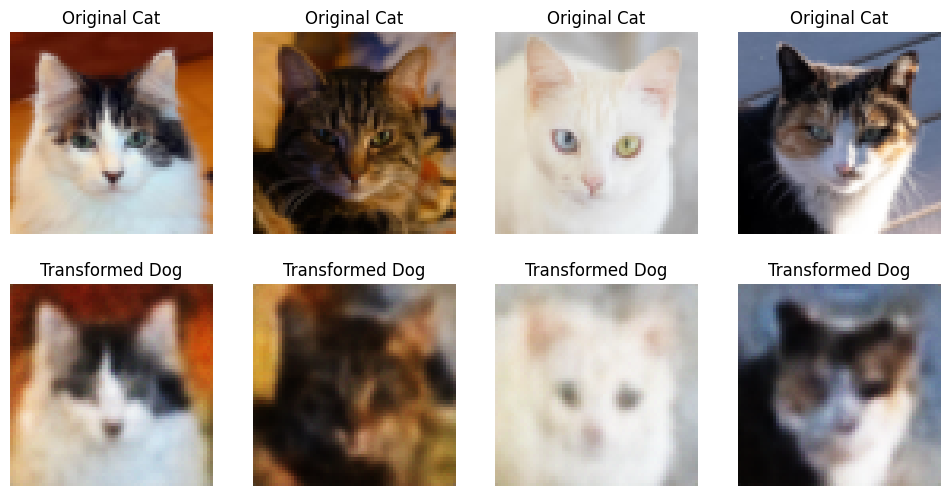

In [108]:
# Load best model
model.load_state_dict(state_dict)
visualize_transformation(model, val_loader, device)

In [109]:
def show_generated_image(model, label):
    z = torch.randn(1, 256).to(device)
    y = torch.tensor([label]).to(device)
    
    # Generate
    recon = model.decode(z, y)
    
    # Move to CPU and format for Plotting (Channels Last)
    # Shape becomes (64, 64, 3)
    img = recon[0].permute(1, 2, 0).detach().cpu().numpy() * 0.5 + 0.5
    
    plt.imshow(img) # Matplotlib treats 0.0-1.0 as valid RGB colors
    plt.title(f"Generated Class {label}")
    plt.show()

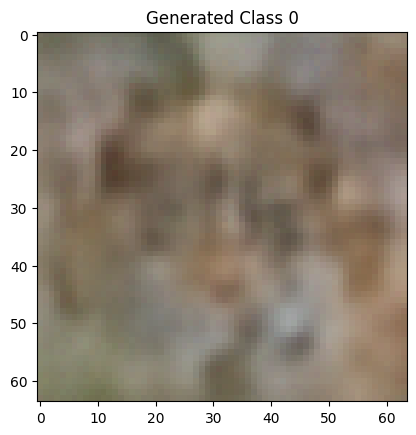

In [139]:
show_generated_image(model, 0)

In [114]:
all_mus = []
with torch.no_grad():
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        mu, _ = model.encode(x, y)
        all_mus.append(mu)

all_mus = torch.cat(all_mus, dim=0)
real_mean = all_mus.mean(dim=0) # The ACTUAL center of your space
real_std = all_mus.std(dim=0)   # The ACTUAL spread of your space
def sample_smart(model, num_samples, device, label_class, real_mean,real_std):
    # 2. Sample using these stats instead of 0 and 1
    # z = real_mean + (noise * real_std)
    z = torch.randn(num_samples, model.latent_dim).to(device)
    z = z * real_std + real_mean
    
    # 3. Decode
    y = torch.full((num_samples,), label_class, dtype=torch.long).to(device)
    recon = model.decode(z, y)
    img = recon[0].permute(1, 2, 0).detach().cpu().numpy() * 0.5 + 0.5
    
    plt.imshow(img) # Matplotlib treats 0.0-1.0 as valid RGB colors
    plt.title(f"Generated Class {label_class}")
    plt.show()
    return 


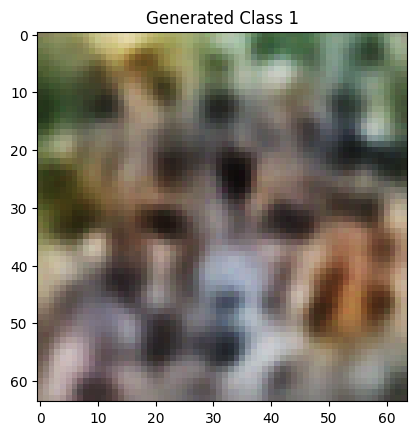

In [135]:
sample_smart(model, 1,device,1, real_mean, real_std)